In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline


In [2]:
# Load Data
try:
    df = pd.read_csv("data/results.csv")
    df = df[df["player"] == "greedy"]
    # Filter to only the target algorithm and embedding
    df = df[(df["embedding"] == "gemini") & (df["algorithm"] == "inv_knn+n_probabilistic")]
    print(f"Loaded {len(df)} rows for gemini & inv_knn+n_probabilistic")
    display(df.head())
except FileNotFoundError:
    print("No results.csv found.")


Loaded 13200 rows for gemini & inv_knn+n_probabilistic


,player,embedding,algorithm,k_nn,n_long,temp,start,target,success,pth_len,opt_len,diff,path_str
12800,greedy,gemini,inv_knn+n_probabilistic,0,5,1.0,stainless,precious,False,-1,5,-1,stainless -> truly -> top -> ru -> color -> pr...
12801,greedy,gemini,inv_knn+n_probabilistic,0,5,1.0,clinic,souls,False,-1,6,-1,clinic -> sept -> du -> mw -> containing -> ve...
12802,greedy,gemini,inv_knn+n_probabilistic,0,5,1.0,flashing,required,False,-1,6,-1,flashing -> determines -> calculations -> they...
12803,greedy,gemini,inv_knn+n_probabilistic,0,5,1.0,reverse,decide,False,-1,6,-1,reverse -> fig -> pace -> sent -> vi -> negoti...
12804,greedy,gemini,inv_knn+n_probabilistic,0,5,1.0,favor,digit,False,-1,6,-1,favor -> au -> fourth -> nz -> millions -> jpe...


In [3]:
# Preprocess data
df['k_nn'] = pd.to_numeric(df['k_nn'], errors='coerce')
df['n_long'] = pd.to_numeric(df['n_long'], errors='coerce')
df['temp'] = pd.to_numeric(df['temp'], errors='coerce')
df['success'] = df['success'].astype(bool)

# Filter for the specific (k,n) combinations
configs_mask = ((df['k_nn'] == 10) & (df['n_long'] == 15)) | ((df['k_nn'] == 15) & (df['n_long'] == 10))
c_df = df[configs_mask].copy()

# Add config label
c_df['config'] = 'k=' + c_df['k_nn'].astype(str) + ', n=' + c_df['n_long'].astype(str)

# Calculate path differences, treating failures as 20
c_df['diff'] = pd.to_numeric(c_df['diff'], errors='coerce')
c_df['diff_adj'] = c_df['diff'].replace(-1, 20).fillna(20)

print(f"Filtered down to {len(c_df)} rows for target configurations.")


Filtered down to 1400 rows for target configurations.


In [4]:
# Group by temp and config to calculate metrics
metrics = c_df.groupby(['config', 'temp']).agg(
    success_rate=('success', 'mean'),
    avg_path_diff=('diff_adj', 'mean')
).reset_index()

display(metrics)


,config,temp,success_rate,avg_path_diff
0,"k=10, n=15",0.1,0.960,4.410
1,"k=10, n=15",0.5,0.940,5.010
2,"k=10, n=15",1.0,0.930,5.355
3,"k=10, n=15",2.0,0.990,3.450
4,"k=10, n=15",5.0,0.970,4.240
5,"k=10, n=15",10.0,0.990,3.450
6,"k=15, n=10",0.1,1.000,2.960
7,"k=15, n=10",0.5,0.990,2.640
8,"k=15, n=10",1.0,0.995,3.205
9,"k=15, n=10",2.0,1.000,2.740


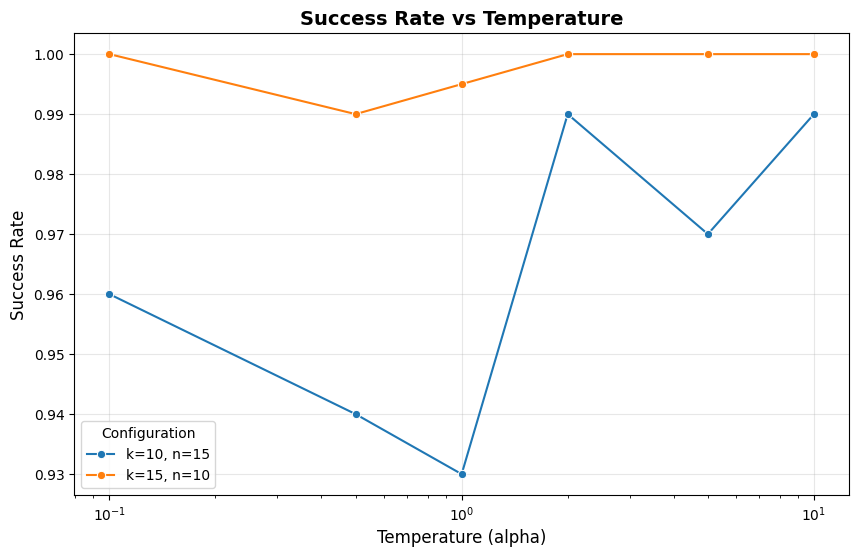

In [5]:
# Plot Success Rate by Temperature
plt.figure(figsize=(10, 6))
sns.lineplot(data=metrics, x='temp', y='success_rate', hue='config', marker='o')

plt.title('Success Rate vs Temperature', fontsize=14, fontweight='bold')
plt.xlabel('Temperature (alpha)', fontsize=12)
plt.ylabel('Success Rate', fontsize=12)
plt.xscale('log') # Temperature values often look better on log scale
plt.grid(True, alpha=0.3)
plt.legend(title='Configuration')

plt.show()


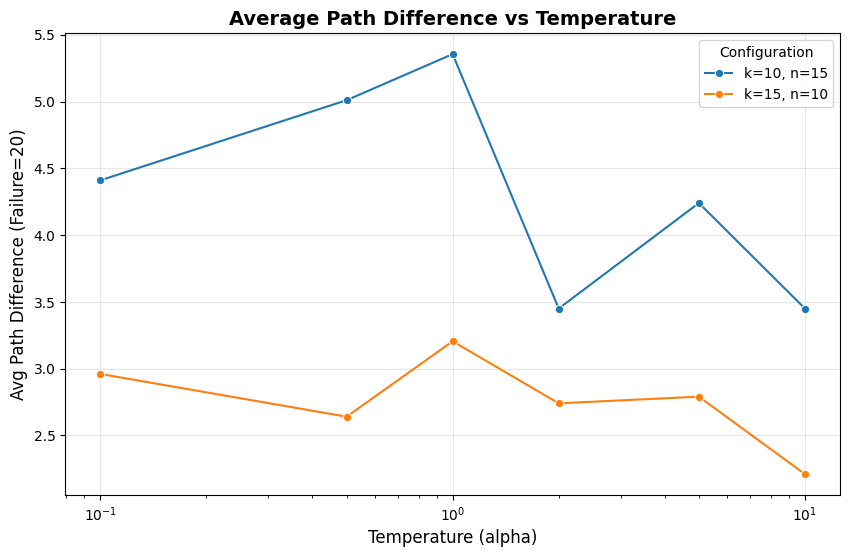

In [6]:
# Plot Max Path Difference by Temperature
plt.figure(figsize=(10, 6))
sns.lineplot(data=metrics, x='temp', y='avg_path_diff', hue='config', marker='o')

plt.title('Average Path Difference vs Temperature', fontsize=14, fontweight='bold')
plt.xlabel('Temperature (alpha)', fontsize=12)
plt.ylabel('Avg Path Difference (Failure=20)', fontsize=12)
plt.xscale('log')
plt.grid(True, alpha=0.3)
plt.legend(title='Configuration')

plt.show()
